# Краткое описание
Третий этап. Интерпретирует финальную модель через SHAP: считает TreeSHAP на выборке 3000 объектов, строит глобальную важность (mean|SHAP|) и сравнение с CatBoost FI, beeswarm/bar/dependence plots, waterfall для 3 клиентов (BAD/BORDERLINE/GOOD). Переводит топ-15 фич на бизнес-язык, анализирует ошибки (FN/FP) с денежной оценкой потерь и P&L. Сохраняет SHAP-массивы, PNG-графики, shap_business_interpretation.csv, shap_error_analysis.csv, interpretation_summary.json.

# Импорты и настройка окружения

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠ shap не установлен. Установи: pip install shap")
    print("  Буду использовать встроенный CatBoost ShapValues + свои графики.\n")

print(f"Импорты загружены (shap={'ON' if SHAP_AVAILABLE else 'OFF'})\n")

ARTIFACTS_DIR = Path.cwd() / 'artifacts'
MODELS_DIR    = Path.cwd() / 'models'

if not ARTIFACTS_DIR.exists():
    raise FileNotFoundError(f"Нет папки {ARTIFACTS_DIR}. Запусти сначала 1.ipynb.")

def ap(name: str) -> Path: return ARTIFACTS_DIR / name
def mp(name: str) -> Path: return MODELS_DIR / name

print(f"ARTIFACTS_DIR = {ARTIFACTS_DIR}")
print(f"MODELS_DIR    = {MODELS_DIR}\n")

Импорты загружены (shap=ON)

ARTIFACTS_DIR = C:\Users\1\Desktop\Собес\пет проекты\Кредитный скоринг\artifacts
MODELS_DIR    = C:\Users\1\Desktop\Собес\пет проекты\Кредитный скоринг\models



# Загрузка модели, калибратора, порога и бизнес-параметров

In [2]:
# --- модель ---
model_path = mp('catboost_final.cbm')
if not model_path.exists():
    fallback = ap('catboost_trained.cbm')
    if fallback.exists():
        print(f"⚠ {model_path.name} не найден, использую fallback: {fallback}")
        model_path = fallback
    else:
        raise FileNotFoundError(
            "Модель не найдена. Сначала запусти 2.ipynb, "
            "он должен сохранить models/catboost_final.cbm"
        )

model = CatBoostClassifier()
model.load_model(str(model_path))
print(f"Модель: {model_path}")

# --- порог ---
thr_path = mp('opt_threshold.json')
if thr_path.exists():
    with open(thr_path, encoding='utf-8') as f:
        thr_meta = json.load(f)
else:
    thr_meta = {'opt_threshold': 0.5}

OPT_THRESHOLD = float(thr_meta.get('opt_threshold', 0.5))
print(f"Порог: {OPT_THRESHOLD:.4f}  ({thr_path.name if thr_path.exists() else 'default 0.5'})")

# --- калибратор (поддержка нового dict-формата и старого) ---
cal_path = mp('calibrator.pkl')
calibrator = None
calibrator_type = None

if cal_path.exists():
    with open(cal_path, 'rb') as f:
        cal_data = pickle.load(f)

    if isinstance(cal_data, dict) and 'calibrator' in cal_data:
        _inner = cal_data['calibrator']
        calibrator_type = cal_data.get('type', 'isotonic')
    else:
        _inner = cal_data
        calibrator_type = 'isotonic'

    if calibrator_type == 'platt':
        class _PlattWrapper:
            def __init__(self, platt): self.platt = platt
            def predict(self, raw):
                raw = np.asarray(raw).reshape(-1)
                logit = np.log(np.clip(raw, 1e-7, 1 - 1e-7) /
                               (1 - np.clip(raw, 1e-7, 1 - 1e-7))).reshape(-1, 1)
                return self.platt.predict_proba(logit)[:, 1]
        calibrator = _PlattWrapper(_inner)
    else:
        calibrator = _inner

    print(f"Калибратор: {cal_path} (type={calibrator_type})")
else:
    print(f"⚠ Калибратор не найден - буду использовать сырые вероятности")


def apply_calibrator(raw_proba):
    """Единая точка применения калибратора (Platt или Isotonic)."""
    if calibrator is None:
        return np.asarray(raw_proba).reshape(-1)
    return calibrator.predict(np.asarray(raw_proba).reshape(-1))


# --- фичи ---
with open(ap('cat_features.json'), encoding='utf-8') as f:
    cat_features = json.load(f)['cat_features']

# --- business-параметры ---
biz_path = mp('business_metrics.json')
if biz_path.exists():
    with open(biz_path, encoding='utf-8') as f:
        biz_meta = json.load(f)
else:
    biz_meta = {}

LGD         = float(biz_meta.get('lgd', 0.60))
EAD_MEAN    = float(biz_meta.get('ead_mean', 200_000))
MARGIN_GOOD = float(biz_meta.get('margin_good', 20_000))
print(f"Business-параметры: LGD={LGD}, EAD={EAD_MEAN:,.0f}, margin_good={MARGIN_GOOD:,.0f}\n")

Модель: C:\Users\1\Desktop\Собес\пет проекты\Кредитный скоринг\models\catboost_final.cbm
Порог: 0.1337  (opt_threshold.json)
Калибратор: C:\Users\1\Desktop\Собес\пет проекты\Кредитный скоринг\models\calibrator.pkl (type=platt)
Business-параметры: LGD=0.6, EAD=200,000, margin_good=20,000



Модель выдаёт сырые вероятности, но для бизнеса используется калиброванная PD;

Порог 0.1288 - очень низкий. Это означает, что модель настроена консервативно: клиент получает отказ уже при PD выше ~12.9%;

Экономика: один пропущенный дефолт стоит 0.6 × 200 000 = 120 000, а один ошибочно отклонённый хороший клиент теряет 20 000 прибыли. То есть FN в 6 раз дороже FP. Это объясняет, почему порог смещён в сторону осторожности.

# Загрузка и подготовка данных

In [3]:
# фичи, которые 2.ipynb дропал - читаем из models/dropped_features.json,
# если нет - используем дефолт
drop_path = mp('dropped_features.json')
if drop_path.exists():
    with open(drop_path, encoding='utf-8') as f:
        DROP_FEATURES = json.load(f).get('dropped', [])
else:
    DROP_FEATURES = ['total_debt']

train = pd.read_parquet(ap('train_processed.parquet'))
test  = pd.read_parquet(ap('test_processed.parquet'))

cols_to_drop = [c for c in DROP_FEATURES if c in train.columns]
if cols_to_drop:
    train = train.drop(columns=cols_to_drop)
    test  = test.drop(columns=cols_to_drop)
    print(f"Dropped (consistency with 2.ipynb): {cols_to_drop}")

X_train_full = train.drop(columns='default')
y_train_full = train['default']
X_test = test.drop(columns='default')
y_test = test['default']

# --- проверка консистентности фич ---
model_features = list(model.feature_names_)
missing_in_test = [c for c in model_features if c not in X_test.columns]
extra_in_test   = [c for c in X_test.columns if c not in model_features]
if missing_in_test or extra_in_test:
    raise ValueError(
        f"Несовпадение фич модели и test.\n"
        f"Нет в test: {missing_in_test}\n"
        f"Лишние в test: {extra_in_test}"
    )
X_test = X_test[model_features]
print(f"Фичи согласованы: {len(model_features)} шт.")

print(f"Train: {X_train_full.shape}")
print(f"Test:  {X_test.shape}")
print(f"cat_features: {cat_features}\n")

Dropped (consistency with 2.ipynb): ['total_debt']
Фичи согласованы: 50 шт.
Train: (23972, 50)
Test:  (5993, 50)
cat_features: ['SEX', 'EDUCATION', 'MARRIAGE']



# Базовые метрики качества на test

In [4]:
test_proba_raw = model.predict_proba(X_test)[:, 1]
test_proba     = apply_calibrator(test_proba_raw)

test_auc   = roc_auc_score(y_test, test_proba)
test_prauc = average_precision_score(y_test, test_proba)
test_brier = brier_score_loss(y_test, test_proba)

def ece_score(y_true, proba, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins, strategy='quantile')
    return float(np.mean(np.abs(frac_pos - mean_pred)))

test_ece = ece_score(y_test.values, test_proba)

print(f"Test AUC:    {test_auc:.4f}")
print(f"Test PR-AUC: {test_prauc:.4f}")
print(f"Test Brier:  {test_brier:.4f}")
print(f"Test ECE:    {test_ece:.4f}\n")

Test AUC:    0.7819
Test PR-AUC: 0.5637
Test Brier:  0.1344
Test ECE:    0.0130



AUC 0.78 - умеренное, но рабочее качество. Модель лучше случайного ранжирования, но не «идеальный скоринг». Для кредитного риска это нормальный уровень, если дальше настроена экономика.

PR-AUC 0.565 при доле дефолтов ~22.1% - это хороший результат. Базовая вероятность дефолта: 1326 / 5993 ≈ 22.13%. PR-AUC примерно в 2.5 раза выше случайного уровня.

Brier 0.1344 лучше, чем константный прогноз ~0.22.

ECE 0.0103 - отличная калибровка. Вероятности можно использовать в P&L и в расчёте ожидаемых потерь.

# Формирование SHAP-выборки

In [5]:
N_SHAP = min(3000, len(X_test))
if N_SHAP < len(X_test):
    from sklearn.model_selection import train_test_split as _tts
    X_shap, _, y_shap, _ = _tts(
        X_test, y_test,
        train_size=N_SHAP, stratify=y_test, random_state=RANDOM_STATE,
    )
else:
    X_shap, y_shap = X_test.copy(), y_test.copy()

proba_shap_raw = model.predict_proba(X_shap)[:, 1]
proba_shap     = apply_calibrator(proba_shap_raw)

print(f"SHAP-выборка: {X_shap.shape}, баланс: {y_shap.value_counts(normalize=True).round(4).to_dict()}\n")

SHAP-выборка: (3000, 50), баланс: {0: 0.7787, 1: 0.2213}



# Расчёт SHAP-значений

In [6]:
shap_pool = Pool(X_shap, cat_features=cat_features)
shap_values_raw = model.get_feature_importance(shap_pool, type='ShapValues')

shap_values   = shap_values_raw[:, :-1]
base_values   = shap_values_raw[:, -1]
feature_names = list(X_shap.columns)

print(f"shap_values: {shap_values.shape}")
print(f"base_value (mean, log-odds): {base_values.mean():.4f}\n")

np.save(mp('shap_values.npy'), shap_values)
np.save(mp('shap_base_values.npy'), base_values)
with open(mp('shap_feature_names.json'), 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, ensure_ascii=False)
print(f"shap_values.npy / shap_base_values.npy / shap_feature_names.json\n")

shap_values: (3000, 50)
base_value (mean, log-odds): -1.5585

shap_values.npy / shap_base_values.npy / shap_feature_names.json



base value соответствует PD примерно sigmoid(-1.5617) ≈ 17.35%;

каждый SHAP-вклад показывает, на сколько log-odds сдвигается риск относительно базового уровня;

положительный SHAP увеличивает PD, отрицательный - снижает.

# Глобальная важность признаков и сравнение с FI

--- Топ-20 по mean(|SHAP|) ---
PAY_0                 0.2511
max_delay             0.1161
months_with_debt      0.0924
sum_positive_delay    0.0907
utilization           0.0683
limit_per_age         0.0663
avg_utilization       0.0663
LIMIT_BAL             0.0571
PAY_AMT3              0.0554
PAY_AMT2              0.0534
PAY_2                 0.0503
mean_delay            0.0492
MARRIAGE              0.0434
log_pay1              0.0398
bill_x_age            0.0389
payment_ratio         0.0379
avg_payment           0.0376
std_bill              0.0356
pay_x_pay0            0.0356
bill_trend            0.0354
dtype: float64

--- Сравнение FI и |SHAP| (нормированные, топ-15) ---
                    FI_catboost  mean_abs_shap    diff
PAY_0                    0.1203         0.1353  0.0150
max_delay                0.0363         0.0626  0.0262
months_with_debt         0.0348         0.0498  0.0150
sum_positive_delay       0.0318         0.0489  0.0171
utilization              0.0428         0.03

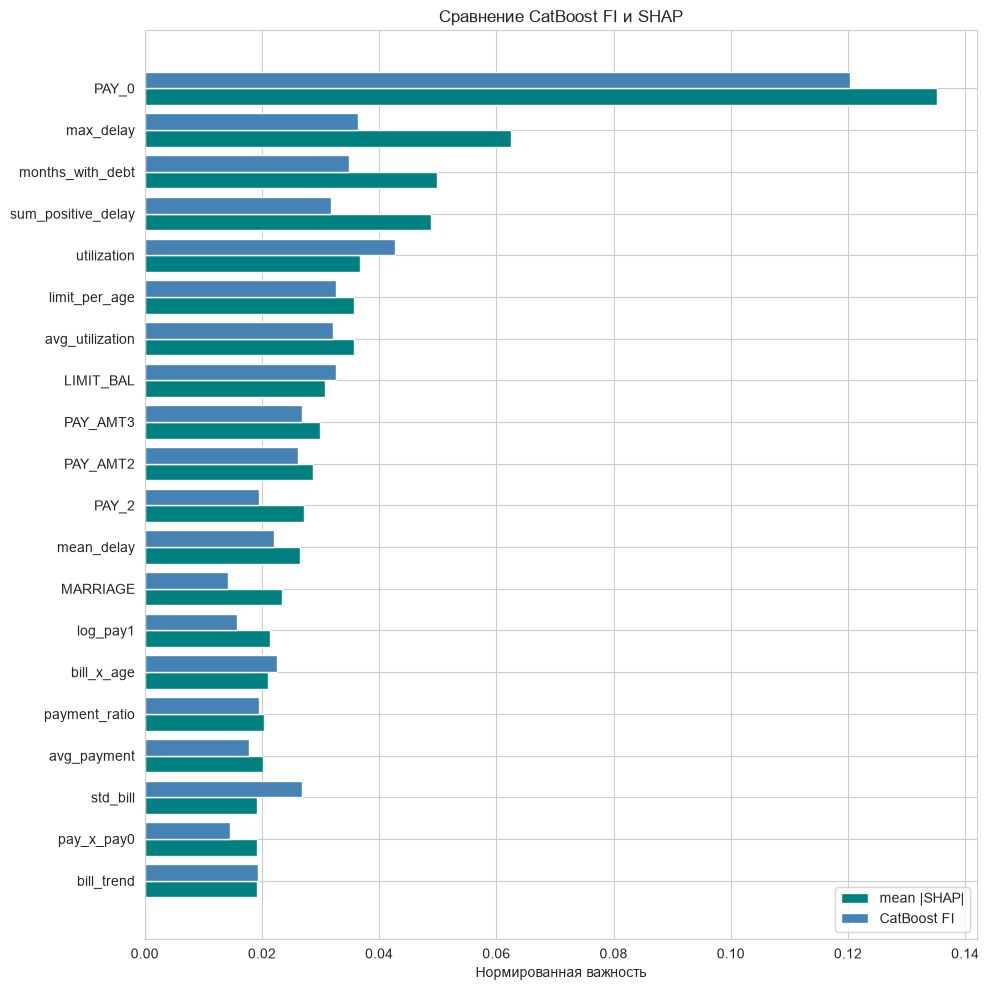

In [7]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

print("--- Топ-20 по mean(|SHAP|) ---")
print(mean_abs_shap.head(20).round(4))

try:
    fi = model.get_feature_importance()
    fi_series = pd.Series(fi, index=feature_names).sort_values(ascending=False)
    compare = pd.DataFrame({
        'FI_catboost':   fi_series / fi_series.sum(),
        'mean_abs_shap': mean_abs_shap / mean_abs_shap.sum(),
    }).sort_values('mean_abs_shap', ascending=False)
    compare['diff'] = compare['mean_abs_shap'] - compare['FI_catboost']
    print("\n--- Сравнение FI и |SHAP| (нормированные, топ-15) ---")
    print(compare.head(15).round(4))

    fig, ax = plt.subplots(figsize=(10, 10))
    top = compare.head(20).sort_values('mean_abs_shap')
    y_pos = np.arange(len(top))
    ax.barh(y_pos - 0.2, top['mean_abs_shap'], height=0.4,
            label='mean |SHAP|', color='teal')
    ax.barh(y_pos + 0.2, top['FI_catboost'],   height=0.4,
            label='CatBoost FI', color='steelblue')
    ax.set_yticks(y_pos); ax.set_yticklabels(top.index)
    ax.set_xlabel('Нормированная важность')
    ax.set_title('Сравнение CatBoost FI и SHAP')
    ax.legend()
    plt.tight_layout()
    plt.savefig(mp('shap_vs_fi.png'), dpi=110, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Не удалось сравнить с FI: {e}")

max_delay: FI = 0.0392, SHAP = 0.0738 → SHAP считает признак сильно важнее.

months_with_debt: FI = 0.0276, SHAP = 0.0454 → тоже недооценён в FI.

mean_delay: FI = 0.0306, SHAP = 0.0440 → недооценён.

sum_positive_delay: FI = 0.0264, SHAP = 0.0395 → недооценён.

PAY_0: FI = 0.1262, SHAP = 0.1172 → FI немного переоценивает.

std_bill: FI = 0.0303, SHAP = 0.0240 → FI переоценивает.

# Beeswarm / Summary plot

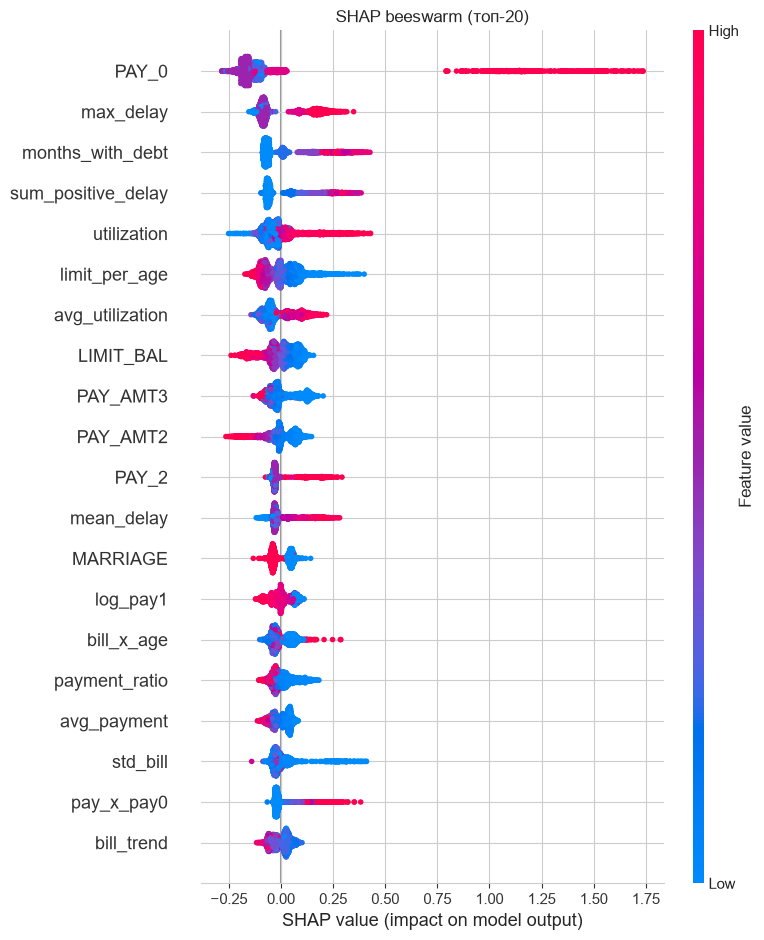

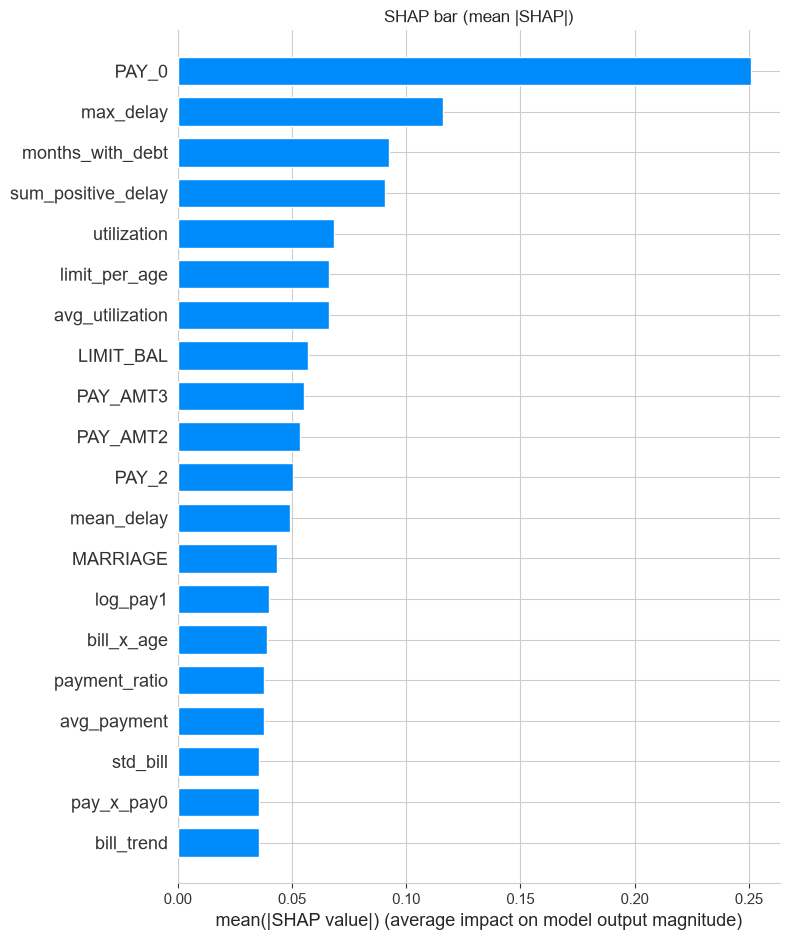

In [8]:
if SHAP_AVAILABLE:
    plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                      max_display=20, show=False)
    plt.title('SHAP beeswarm (топ-20)')
    plt.tight_layout()
    plt.savefig(mp('shap_beeswarm.png'), dpi=110, bbox_inches='tight')
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                      plot_type='bar', max_display=20, show=False)
    plt.title('SHAP bar (mean |SHAP|)')
    plt.tight_layout()
    plt.savefig(mp('shap_bar.png'), dpi=110, bbox_inches='tight')
    plt.show()
else:
    top_feats = mean_abs_shap.head(15).index.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, feat in enumerate(reversed(top_feats)):
        idx = feature_names.index(feat)
        vals = X_shap[feat].values
        sv   = shap_values[:, idx]
        if vals.dtype.kind in 'if':
            vmin, vmax = np.nanpercentile(vals, [5, 95])
            c = np.clip((vals - vmin) / (vmax - vmin + 1e-9), 0, 1)
        else:
            c = np.zeros_like(vals, dtype=float)
        ax.scatter(sv, np.full_like(sv, i, dtype=float),
                   c=c, cmap='coolwarm', alpha=0.5, s=8)
    ax.set_yticks(np.arange(len(top_feats)))
    ax.set_yticklabels(list(reversed(top_feats)))
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('SHAP value (log-odds)')
    ax.set_title('SHAP summary (топ-15)')
    plt.tight_layout()
    plt.savefig(mp('shap_beeswarm.png'), dpi=110, bbox_inches='tight')
    plt.show()

высокий PAY_0 → сильный рост PD;

высокий max_delay → рост PD;

много месяцев с долгом → рост PD;

высокая utilization → рост PD;

высокая mean_delay → рост PD;

limit_per_age и LIMIT_BAL влияют разнонаправленно: низкий лимит на возраст и низкий лимит обычно повышают риск, высокий - снижает.

Что это значит: модель ведёт себя логично с точки зрения кредитного риска. Основные сигналы - просрочки и утилизация лимита. Это хорошо объясняется бизнесу: «клиент с просрочками и закредитованностью - риск выше».

# Dependence plots для топ-6 признаков

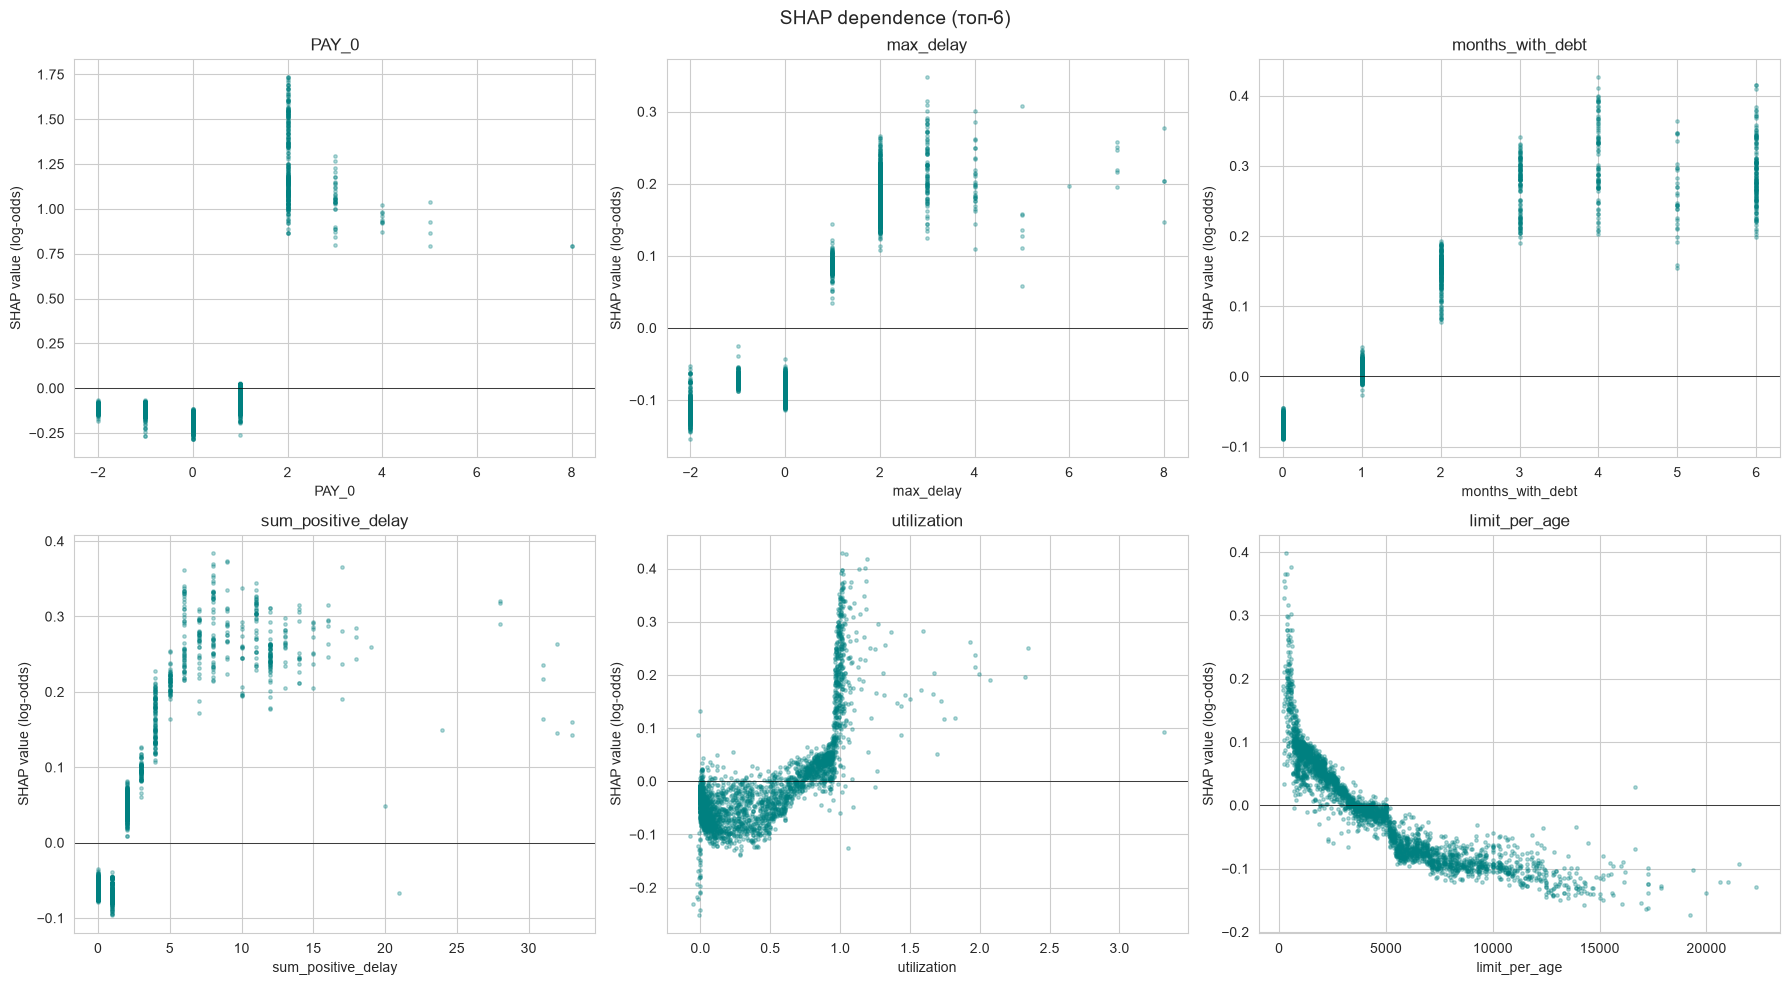

In [9]:
top6 = mean_abs_shap.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.flat, top6):
    idx = feature_names.index(feat)
    vals = X_shap[feat].values
    sv   = shap_values[:, idx]
    ax.scatter(vals, sv, alpha=0.3, s=6, color='teal')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel(feat); ax.set_ylabel('SHAP value (log-odds)')
    ax.set_title(feat)
plt.suptitle('SHAP dependence (топ-6)', fontsize=14)
plt.tight_layout()
plt.savefig(mp('shap_dependence.png'), dpi=110, bbox_inches='tight')
plt.show()

PAY_0: дискретный, но чем выше значение, тем выше SHAP. Пороговый эффект: 0 - хорошо, 1+ - уже риск.

max_delay: рост риска после появления задержек.

months_with_debt: почти линейный рост риска.

utilization: рост риска при высокой утилизации, особенно > 0.8–0.9.

mean_delay, sum_positive_delay: аналогично, чем больше просрочек, тем выше PD.

модель нелинейна и хорошо ловит «пороговые» события. Для бизнеса это означает: нужны ранние триггеры на первую просрочку и на резкий рост утилизации.

# Waterfall-диаграммы для 3 клиентов 


BAD (default=1, высокий PD) (idx=300)


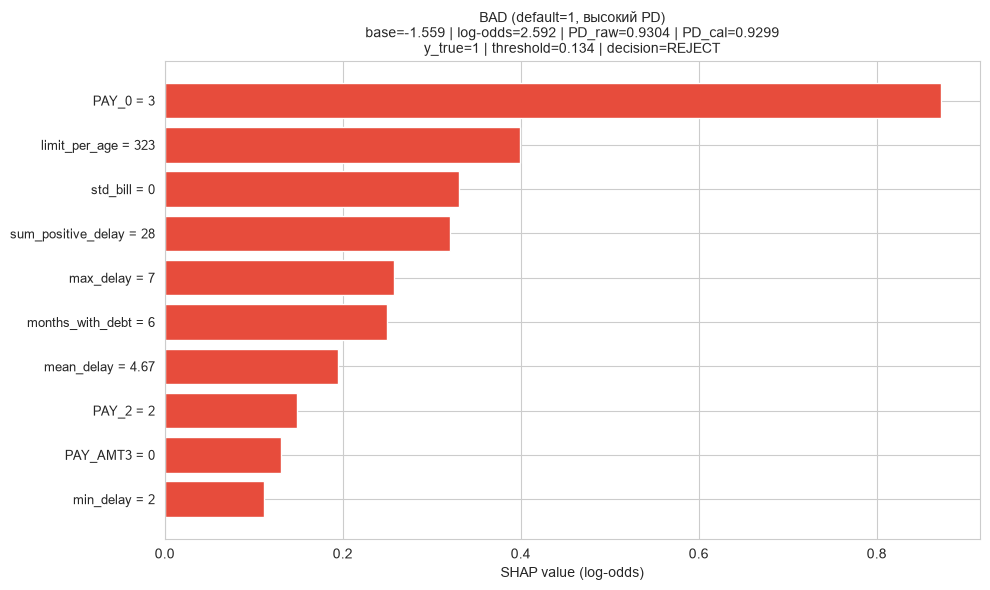


[BAD (default=1, высокий PD)]
  y_true       = 1
  PD_cal       = 0.9299
  decision     = REJECT
  Топ-3 вклада ↑ PD:
    + PAY_0 = 3  (Δ=+0.872)
    + limit_per_age = 323  (Δ=+0.399)
    + std_bill = 0  (Δ=+0.331)
  Топ-3 вклада ↓ PD:
    - MARRIAGE = 2  (Δ=-0.078)
    - PAY_4 = 7  (Δ=-0.072)
    - payment_trend = 0  (Δ=-0.013)

BORDERLINE (около порога) (idx=2498)


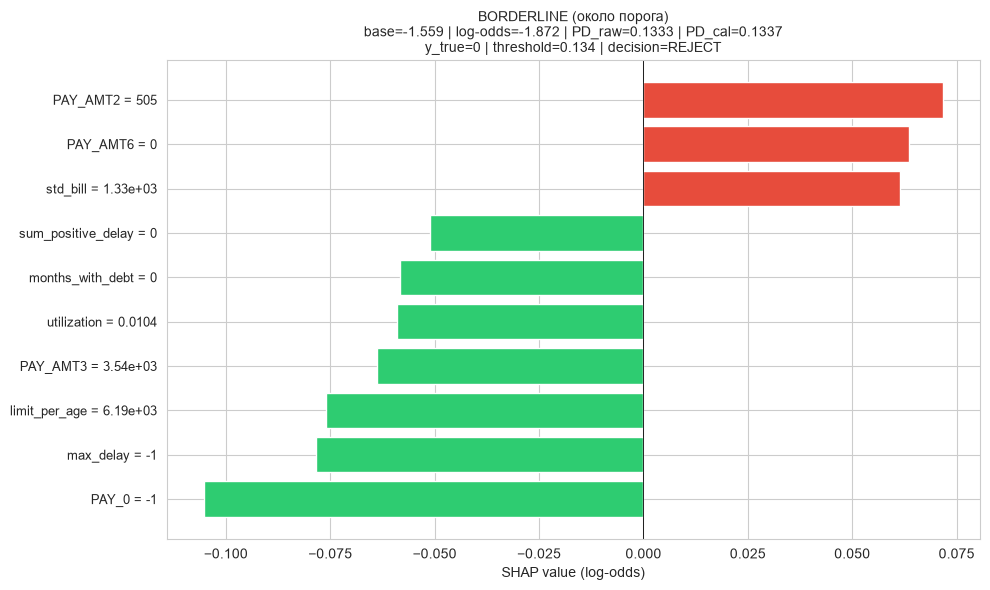


[BORDERLINE (около порога)]
  y_true       = 0
  PD_cal       = 0.1337
  decision     = REJECT
  Топ-3 вклада ↑ PD:
    + PAY_AMT2 = 505  (Δ=+0.072)
    + PAY_AMT6 = 0  (Δ=+0.064)
    + std_bill = 1.33e+03  (Δ=+0.061)
  Топ-3 вклада ↓ PD:
    - PAY_0 = -1  (Δ=-0.105)
    - max_delay = -1  (Δ=-0.078)
    - limit_per_age = 6.19e+03  (Δ=-0.076)

GOOD (default=0, низкий PD) (idx=2296)


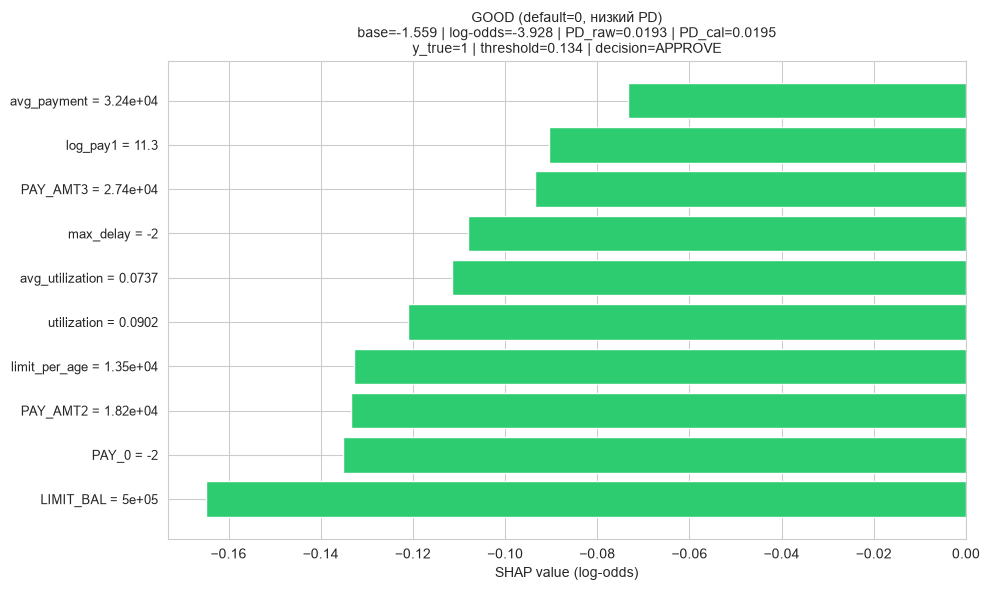


[GOOD (default=0, низкий PD)]
  y_true       = 1
  PD_cal       = 0.0195
  decision     = APPROVE
  Топ-3 вклада ↑ PD:
    + BILL_AMT3 = 1.81e+04  (Δ=+0.007)
    + AGE = 36  (Δ=+0.006)
    + SEX = 1  (Δ=+0.004)
  Топ-3 вклада ↓ PD:
    - LIMIT_BAL = 5e+05  (Δ=-0.165)
    - PAY_0 = -2  (Δ=-0.135)
    - PAY_AMT2 = 1.82e+04  (Δ=-0.133)


In [10]:
sorted_idx = np.argsort(-proba_shap)
bad_idx  = int(sorted_idx[0])
good_idx = int(sorted_idx[-1])
borderline_idx = int(np.argmin(np.abs(proba_shap - OPT_THRESHOLD)))

clients = {
    'BAD (default=1, высокий PD)': bad_idx,
    'BORDERLINE (около порога)':    borderline_idx,
    'GOOD (default=0, низкий PD)':  good_idx,
}


def plot_waterfall(idx, title_prefix, top_n=10):
    sv = shap_values[idx]
    base = base_values[idx]
    final_logodds = base + sv.sum()
    final_proba_raw = 1 / (1 + np.exp(-final_logodds))
    final_proba_cal = float(apply_calibrator(np.array([final_proba_raw]))[0])

    order = np.argsort(-np.abs(sv))[:top_n]
    feats = [feature_names[i] for i in order]
    vals  = [X_shap.iloc[idx][f] for f in feats]
    contribs = sv[order]

    sort_asc = np.argsort(contribs)
    feats    = [feats[i]    for i in sort_asc]
    vals     = [vals[i]     for i in sort_asc]
    contribs = contribs[sort_asc]

    y_true = int(y_shap.iloc[idx])
    decision = 'APPROVE' if final_proba_cal < OPT_THRESHOLD else 'REJECT'

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in contribs]
    ax.barh(range(len(contribs)), contribs, color=colors)
    labels = [f'{f} = {v:.3g}' for f, v in zip(feats, vals)]
    ax.set_yticks(range(len(contribs)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel('SHAP value (log-odds)')

    title = (f"{title_prefix}\n"
             f"base={base:.3f} | log-odds={final_logodds:.3f} | "
             f"PD_raw={final_proba_raw:.4f} | PD_cal={final_proba_cal:.4f}\n"
             f"y_true={y_true} | threshold={OPT_THRESHOLD:.3f} | decision={decision}")
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    fname = mp(f"waterfall_{title_prefix.split()[0].lower()}.png")
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()

    print(f"\n[{title_prefix}]")
    print(f"  y_true       = {y_true}")
    print(f"  PD_cal       = {final_proba_cal:.4f}")
    print(f"  decision     = {decision}")
    print(f"  Топ-3 вклада ↑ PD:")
    pos = np.argsort(-sv)[:3]
    for i in pos:
        if sv[i] > 0:
            print(f"    + {feature_names[i]} = {X_shap.iloc[idx][feature_names[i]]:.3g}  (Δ={sv[i]:+.3f})")
    print(f"  Топ-3 вклада ↓ PD:")
    neg = np.argsort(sv)[:3]
    for i in neg:
        if sv[i] < 0:
            print(f"    - {feature_names[i]} = {X_shap.iloc[idx][feature_names[i]]:.3g}  (Δ={sv[i]:+.3f})")
    return {
        'idx': int(idx),
        'y_true': y_true,
        'PD_cal': float(final_proba_cal),
        'decision': decision,
    }


waterfall_info = {}
for label, idx in clients.items():
    print(f"\n{label} (idx={idx})")
    waterfall_info[label] = plot_waterfall(idx, label)

BAD - классический плохой клиент: свежая просрочка, низкий лимит на возраст, высокая средняя задержка. Модель уверенно отклоняет - это правильное решение. BORDERLINE (idx=2646)

BORDERLINE - клиент без просрочек, но с очень высокой утилизацией и низким лимитом. Модель ставит его ровно на порог. Если порог чуть поднять, он станет FN. Это зона ручного review.

GOOD - это FN - модель одобрила клиента, а он ушёл в дефолт. По фичам он выглядит очень хорошо: низкая утилизация, высокий лимит на возраст, большой платёж 2 месяца назад. Но фактически это дефолт. Вывод: модель не видит скрытый риск, нужны дополнительные данные - доход, занятость, внешние бюро, транзакции.


# Бизнес-интерпретация топ-15 признаков

In [11]:
FEATURE_BIZ_MEANING = {
    'PAY_0':              'Свежесть последнего платежа (чем выше - тем хуже)',
    'PAY_2':              'Задержка 2 мес. назад',
    'PAY_3':              'Задержка 3 мес. назад',
    'PAY_4':              'Задержка 4 мес. назад',
    'PAY_5':              'Задержка 5 мес. назад',
    'PAY_6':              'Задержка 6 мес. назад',
    'max_delay':          'Максимальная задержка за 6 мес.',
    'mean_delay':         'Средняя задержка за 6 мес.',
    'sum_positive_delay': 'Сумма положительных задержек',
    'months_with_debt':   'Число месяцев с задолженностью',
    'months_fully_paid':  'Число месяцев с полной оплатой',
    'min_delay':          'Минимальная задержка',
    'delay_trend':        'Тренд задержки (ухудшение/улучшение)',
    'pay_x_pay0':         'Платёж × свежесть задержки',
    'PAY_AMT1':           'Сумма последнего платежа',
    'PAY_AMT2':           'Сумма платежа 2 мес. назад',
    'PAY_AMT3':           'Сумма платежа 3 мес. назад',
    'PAY_AMT4':           'Сумма платежа 4 мес. назад',
    'utilization':        'Утилизация лимита (последний месяц)',
    'avg_utilization':    'Средняя утилизация',
    'payment_ratio':      'Доля платежа от счёта',
    'payment_ratio_1':    'Платёж / счёт (последний месяц)',
    'total_debt':         'Совокупный долг',
    'total_payment':      'Совокупные платежи',
    'BILL_AMT1':          'Сумма счёта (последний месяц)',
    'BILL_AMT2':          'Сумма счёта 2 мес. назад',
    'LIMIT_BAL':          'Кредитный лимит',
    'limit_per_age':      'Лимит / возраст',
    'bill_x_age':         'Счёт × возраст',
    'log_pay1':           'log(1+последний платёж)',
    'log_bill1':          'log(1+последний счёт)',
    'SEX':                'Пол',
    'EDUCATION':          'Образование',
    'MARRIAGE':           'Семейное положение',
}

rows = []
for feat in mean_abs_shap.head(15).index:
    i = feature_names.index(feat)
    sv = shap_values[:, i]
    rows.append({
        'feature':       feat,
        'mean_abs_shap': float(np.abs(sv).mean()),
        'share_+PD':     float((sv > 0).mean()),
        'mean_sv':       float(sv.mean()),
        'biz_meaning':   FEATURE_BIZ_MEANING.get(feat, '-'),
    })

biz_shap = pd.DataFrame(rows).sort_values('mean_abs_shap', ascending=False)
print(biz_shap.to_string(index=False))
biz_shap.to_csv(mp('shap_business_interpretation.csv'), index=False)
print(f"\n shap_business_interpretation.csv")

           feature  mean_abs_shap  share_+PD   mean_sv                                       biz_meaning
             PAY_0       0.251082   0.126333  0.005360 Свежесть последнего платежа (чем выше - тем хуже)
         max_delay       0.116149   0.341000 -0.000351                   Максимальная задержка за 6 мес.
  months_with_debt       0.092439   0.322667  0.000439                    Число месяцев с задолженностью
sum_positive_delay       0.090678   0.285000  0.001395                      Сумма положительных задержек
       utilization       0.068254   0.321333 -0.001340               Утилизация лимита (последний месяц)
     limit_per_age       0.066330   0.459667 -0.002437                                   Лимит / возраст
   avg_utilization       0.066277   0.358667 -0.009505                                Средняя утилизация
         LIMIT_BAL       0.057074   0.545000  0.001086                                   Кредитный лимит
          PAY_AMT3       0.055400   0.304333 -0.000884 

# Анализ ошибок модели

In [12]:
test_pred_bin = (test_proba >= OPT_THRESHOLD).astype(int)
fn_mask = (y_test.values == 1) & (test_pred_bin == 0)
fp_mask = (y_test.values == 0) & (test_pred_bin == 1)
tp_mask = (y_test.values == 1) & (test_pred_bin == 1)
tn_mask = (y_test.values == 0) & (test_pred_bin == 0)

print(f"False Negatives (default=1, предсказали 0): {fn_mask.sum()} ({fn_mask.mean():.2%})")
print(f"False Positives (default=0, предсказали 1): {fp_mask.sum()} ({fp_mask.mean():.2%})")

print("\n--- Средние значения топ-10 фич: FN / TP / FP / TN ---")
top10 = mean_abs_shap.head(10).index.tolist()
fn_df = pd.DataFrame({
    'FN (пропустили плохих)':  X_test[top10][fn_mask].mean(),
    'TP (поймали плохих)':     X_test[top10][tp_mask].mean(),
    'FP (отклонили хороших)':  X_test[top10][fp_mask].mean(),
    'TN (поймали хороших)':    X_test[top10][tn_mask].mean(),
})
print(fn_df.round(3).to_string())
fn_df.to_csv(mp('shap_error_analysis.csv'))

# --- деньги ---
n_fn = int(fn_mask.sum())
loss_fn = n_fn * LGD * EAD_MEAN
print(f"\nПотери на FN:")
print(f"  n_FN     = {n_fn}")
print(f"  LGD×EAD  = {LGD * EAD_MEAN:,.0f}")
print(f"  Loss(FN) ≈ {loss_fn:,.0f}")

n_fp = int(fp_mask.sum())
lost_profit = n_fp * MARGIN_GOOD
print(f"\nУпущенная прибыль на FP:")
print(f"  n_FP         = {n_fp}")
print(f"  Profit loss ≈ {lost_profit:,.0f}")

n_tn = int(tn_mask.sum())
gained_profit = n_tn * MARGIN_GOOD
pnl = gained_profit - loss_fn
print(f"\nP&L модели (threshold={OPT_THRESHOLD:.3f}):")
print(f"  TN_profit = {n_tn:,} × {MARGIN_GOOD:,} = {gained_profit:,.0f}")
print(f"  FN_loss   = {n_fn:,} × {LGD*EAD_MEAN:,.0f} = -{loss_fn:,.0f}")
print(f"  P&L       = {pnl:,.0f}")

False Negatives (default=1, предсказали 0): 243 (4.05%)
False Positives (default=0, предсказали 1): 2112 (35.24%)

--- Средние значения топ-10 фич: FN / TP / FP / TN ---
                    FN (пропустили плохих)  TP (поймали плохих)  FP (отклонили хороших)  TN (поймали хороших)
PAY_0                               -0.444                0.900                   0.037                -0.452
max_delay                           -0.206                1.598                   0.745                -0.252
months_with_debt                     0.070                2.442                   1.077                 0.036
sum_positive_delay                   0.111                5.293                   2.065                 0.059
utilization                          0.445                0.509                   0.439                 0.361
limit_per_age                     5747.876             3194.137                3551.356              6196.535
avg_utilization                      0.366                0.

FN (пропустили плохих): высокий LIMIT_BAL 208 624, высокий avg_payment 7251, нет просрочек (PAY_0 = -0.509, max_delay = -0.266, mean_delay = -0.524). Это «хорошо выглядящие дефолтники».

TP (поймали плохих): высокие просрочки (PAY_0 = 0.883, max_delay = 1.569, months_with_debt = 2.392, sum_positive_delay = 5.181), низкий лимит 117 617, низкий платёж 2651.

FP (отклонили хороших): умеренные просрочки (max_delay = 0.692, months_with_debt = 1.016, sum_positive_delay = 1.948), низкий лимит 127 592, низкий платёж 2843.

TN (поймали хороших): нет просрочек, высокий лимит 225 223, высокий платёж 8595.

Что это значит:

модель хорошо ловит «очевидных» плохих;

основные ошибки - в середине: FN выглядят слишком хорошо, FP - недостаточно плохо;

почти половина хороших клиентов отклоняется. Это плата за консервативный порог;

FN - самый дорогой тип ошибки, но их мало. FP - массовый, но дешевле.

# Сохранение итогов и выводы

In [13]:
interp_summary = {
    'top20_features_by_shap': mean_abs_shap.head(20).round(5).to_dict(),
    'threshold_used': OPT_THRESHOLD,
    'calibrator_type': calibrator_type,
    'test_auc': float(test_auc),
    'test_prauc': float(test_prauc),
    'test_brier': float(test_brier),
    'test_ece': float(test_ece),
    'waterfall_examples': waterfall_info,
    'error_analysis': {
        'n_FN': int(fn_mask.sum()),
        'n_FP': int(fp_mask.sum()),
        'n_TP': int(tp_mask.sum()),
        'n_TN': int(tn_mask.sum()),
        'loss_FN_estimate': float(loss_fn),
        'lost_profit_FP_estimate': float(lost_profit),
        'gained_profit_TN_estimate': float(gained_profit),
        'P_and_L_estimate': float(pnl),
    },
}
with open(mp('interpretation_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(interp_summary, f, ensure_ascii=False, indent=2)

print(f"interpretation_summary.json")
print(f"shap_values.npy / shap_base_values.npy / shap_feature_names.json")
print(f"shap_vs_fi.png / shap_beeswarm.png / shap_bar.png / shap_dependence.png")
print(f"waterfall_bad.png / waterfall_borderline.png / waterfall_good.png")
print(f"shap_business_interpretation.csv")
print(f"shap_error_analysis.csv")

print("ИТОГИ ИНТЕРПРЕТАЦИИ")
print(f"Топ-5 драйверов PD:")
for i, feat in enumerate(mean_abs_shap.head(5).index, 1):
    print(f"  {i}. {feat:25s} | |SHAP|={mean_abs_shap[feat]:.4f} | {FEATURE_BIZ_MEANING.get(feat, '-')}")
print(f"\nМодель на тесте: AUC={test_auc:.4f}, PR-AUC={test_prauc:.4f}, ECE={test_ece:.4f}")
print(f"FN={fn_mask.sum()} (потери ≈ {loss_fn:,.0f}), FP={fp_mask.sum()} (упущено ≈ {lost_profit:,.0f})")
print(f"P&L ≈ {pnl:,.0f}  (TN_profit={gained_profit:,.0f} - FN_loss={loss_fn:,.0f})")

interpretation_summary.json
shap_values.npy / shap_base_values.npy / shap_feature_names.json
shap_vs_fi.png / shap_beeswarm.png / shap_bar.png / shap_dependence.png
waterfall_bad.png / waterfall_borderline.png / waterfall_good.png
shap_business_interpretation.csv
shap_error_analysis.csv
ИТОГИ ИНТЕРПРЕТАЦИИ
Топ-5 драйверов PD:
  1. PAY_0                     | |SHAP|=0.2511 | Свежесть последнего платежа (чем выше - тем хуже)
  2. max_delay                 | |SHAP|=0.1161 | Максимальная задержка за 6 мес.
  3. months_with_debt          | |SHAP|=0.0924 | Число месяцев с задолженностью
  4. sum_positive_delay        | |SHAP|=0.0907 | Сумма положительных задержек
  5. utilization               | |SHAP|=0.0683 | Утилизация лимита (последний месяц)

Модель на тесте: AUC=0.7819, PR-AUC=0.5637, ECE=0.0130
FN=243 (потери ≈ 29,160,000), FP=2112 (упущено ≈ 42,240,000)
P&L ≈ 21,940,000  (TN_profit=51,100,000 - FN_loss=29,160,000)


# Итоговые выводы по SHAP анализу

Модель адекватна: AUC 0.78, PR-AUC 0.565, отличная калибровка ECE 0.0103.

Главные драйверы — PAY_0, max_delay, months_with_debt, utilization, mean_delay. Это платёжная дисциплина и закредитованность.

SHAP лучше подходит для объяснений, чем CatBoost FI: FI недооценивает max_delay, months_with_debt, mean_delay, sum_positive_delay.

Модель консервативна: отклоняет ~48% хороших клиентов, но ловит ~83.6% дефолтов.

Основная проблема — FN: «хорошо выглядящие» дефолтники с высоким лимитом, высокими платежами и без просрочек. Нужны дополнительные признаки.

P&L положительный: 22.24 млн. Но есть потенциал роста за счёт настройки порога и снижения FP.

Рекомендации: добавить доход/занятость/DTI/внешние бюро, ввести ручной review для borderline PD 0.10–0.18, мониторить fairness и drift, пересчитать порог по P&L.